<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Outliers**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis or EDA. 
You will explore the distribution of key variables and focus on identifying outliers in this lab.


## Objectives


In this lab, you will perform the following:


-  Analyze the distribution of key variables in the dataset.

-  Identify and remove outliers using statistical methods.

-  Perform relevant statistical and correlation analysis.


#### Install and import the required libraries


In [1]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h3>Step 1: Load and Explore the Dataset</h3>


Load the dataset into a DataFrame and examine the structure of the data.


In [2]:
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

#Create the dataframe
df = pd.read_csv(file_url)

#Display the top 10 records
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


<h3>Step 2: Plot the Distribution of Industry</h3>


Explore how respondents are distributed across different industries.

- Plot a bar chart to visualize the distribution of respondents by industry.

- Highlight any notable trends.


In [3]:
df.columns

Index(['ResponseId', 'MainBranch', 'Age', 'Employment', 'RemoteWork', 'Check',
       'CodingActivities', 'EdLevel', 'LearnCode', 'LearnCodeOnline',
       ...
       'JobSatPoints_6', 'JobSatPoints_7', 'JobSatPoints_8', 'JobSatPoints_9',
       'JobSatPoints_10', 'JobSatPoints_11', 'SurveyLength', 'SurveyEase',
       'ConvertedCompYearly', 'JobSat'],
      dtype='object', length=114)

In [4]:
[col for col in df.columns if 'industry' in col.lower()]

['Industry']

In [5]:
df['Industry'].value_counts().head(10)

Industry
Software Development                          11918
Other:                                         3077
Fintech                                        1641
Internet, Telecomm or Information Services     1629
Banking/Financial Services                     1371
Healthcare                                     1277
Manufacturing                                  1265
Retail and Consumer Services                   1264
Government                                      962
Media & Advertising Services                    894
Name: count, dtype: int64

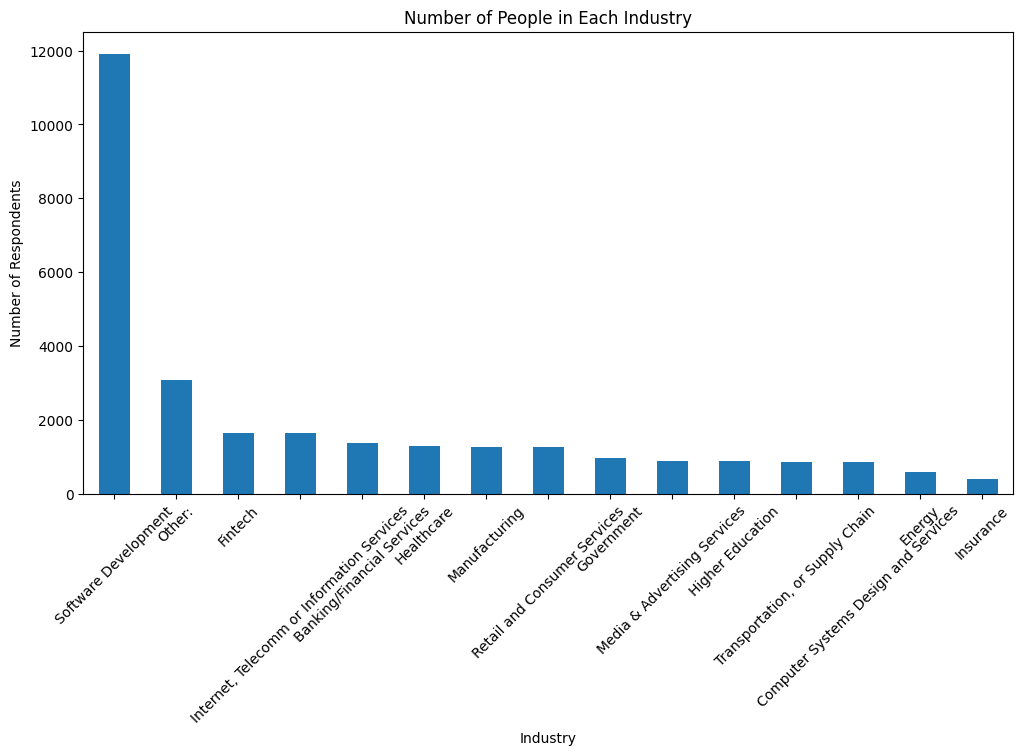

In [6]:
df['Industry'].value_counts().head(15).plot(kind='bar', figsize=(12,6))
plt.title('Number of People in Each Industry')
plt.xlabel('Industry')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.show()

<h3>Step 3: Identify High Compensation Outliers</h3>


Identify respondents with extremely high yearly compensation.

- Calculate basic statistics (mean, median, and standard deviation) for `ConvertedCompYearly`.

- Identify compensation values exceeding a defined threshold (e.g., 3 standard deviations above the mean).


In [7]:
df['ConvertedCompYearly'].describe()

count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64

In [8]:
mean_comp = df['ConvertedCompYearly'].mean()
median_comp = df['ConvertedCompYearly'].median()
std_comp = df['ConvertedCompYearly'].std()

print(f"The MEAN for ConvertedCompYearly is: {mean_comp}")
print(f"The MEDIAN for ConvertedCompYearly is: {median_comp}")
print(f"The STANDARD DEVIATION for ConvertedCompYearly is: {std_comp}")

The MEAN for ConvertedCompYearly is: 86155.28726264134
The MEDIAN for ConvertedCompYearly is: 65000.0
The STANDARD DEVIATION for ConvertedCompYearly is: 186756.97308629757


In [9]:
threshold = mean_comp + (3 * std_comp)
print(f"The outlier threshold is: {threshold}")

The outlier threshold is: 646426.2065215341


In [10]:
outliers = df[df['ConvertedCompYearly'] > threshold]
print(f"Number of outliers: {len(outliers)}")

Number of outliers: 89


In [11]:
outliers[['ConvertedCompYearly']].sort_values(by='ConvertedCompYearly', ascending=False)

,ConvertedCompYearly
15837,16256603.0
12723,13818022.0
28379,9000000.0
17593,6340564.0
17672,4936778.0
...,...
13336,660660.0
6735,650000.0
529,650000.0
28381,650000.0


In [12]:
outliers[['ConvertedCompYearly', 'Country', 'Employment', 'EdLevel']].sort_values(by='ConvertedCompYearly', ascending=False)

,ConvertedCompYearly,Country,Employment,EdLevel
15837,16256603.0,Ethiopia,"Independent contractor, freelancer, or self-em...","Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
12723,13818022.0,South Africa,"Employed, full-time;Independent contractor, fr...","Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
28379,9000000.0,Taiwan,"Employed, full-time","Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
17593,6340564.0,Brazil,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
17672,4936778.0,Ukraine,"Employed, full-time","Professional degree (JD, MD, Ph.D, Ed.D, etc.)"
...,...,...,...,...
13336,660660.0,Pakistan,"Employed, part-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
6735,650000.0,United States of America,"Employed, full-time","Master’s degree (M.A., M.S., M.Eng., MBA, etc.)"
529,650000.0,United States of America,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)"
28381,650000.0,United States of America,"Employed, full-time","Bachelor’s degree (B.A., B.S., B.Eng., etc.)"


<h3>Step 4: Detect Outliers in Compensation</h3>


Identify outliers in the `ConvertedCompYearly` column using the IQR method.

- Calculate the Interquartile Range (IQR).

- Determine the upper and lower bounds for outliers.

- Count and visualize outliers using a box plot.


In [17]:
Q1 = df['ConvertedCompYearly'].quantile(0.25)
print(Q1)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
print(Q3)

32712.0
107971.5


In [ ]:
IQR = Q3 - Q1

In [16]:
print(IQR)

75259.5


In [18]:
lower_bound = Q1 - 1.5*IQR
print(lower_bound)
upper_bound = Q3 + 1.5*IQR
print(upper_bound)

-80177.25
220860.75


In [21]:
outliers = df[(df['ConvertedCompYearly'] < lower_bound) | (df['ConvertedCompYearly'] > upper_bound)]
print(len(outliers))

978


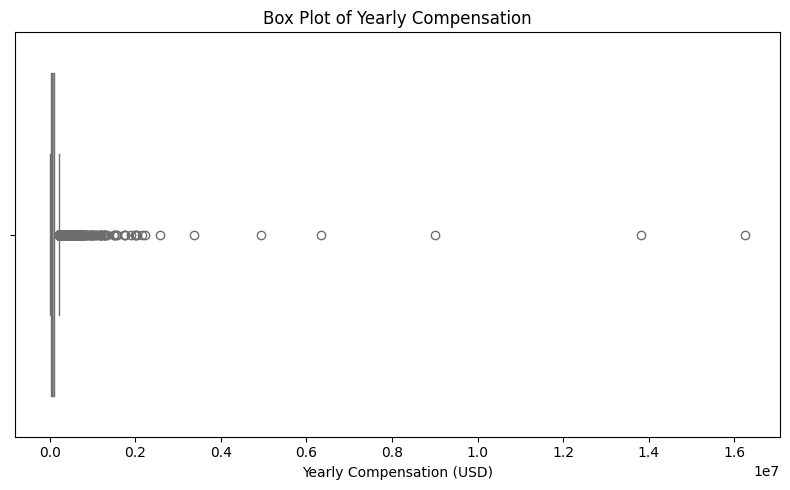

In [22]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ConvertedCompYearly'], color='lightcoral')
plt.title("Box Plot of Yearly Compensation")
plt.xlabel("Yearly Compensation (USD)")
plt.tight_layout()
plt.show()

<h3>Step 5: Remove Outliers and Create a New DataFrame</h3>


Remove outliers from the dataset.

- Create a new DataFrame excluding rows with outliers in `ConvertedCompYearly`.
- Validate the size of the new DataFrame.


In [23]:
df_no_outliers = df[(df['ConvertedCompYearly'] >= lower_bound) & (df['ConvertedCompYearly'] <= upper_bound)]

In [24]:
print("Original dataset:", len(df))
print("Dataset without outliers:", len(df_no_outliers))

Original dataset: 65437
Dataset without outliers: 22457


<h3>Step 6: Correlation Analysis</h3>


Analyze the correlation between `Age` (transformed) and other numerical columns.

- Map the `Age` column to approximate numeric values.

- Compute correlations between `Age` and other numeric variables.

- Visualize the correlation matrix.


In [25]:
print(df_no_outliers['Age'].unique())

['18-24 years old' '25-34 years old' '35-44 years old' '45-54 years old'
 '55-64 years old' '65 years or older' 'Under 18 years old'
 'Prefer not to say']


In [26]:
age_mapping = {
    'Under 18 years old': 17,
    '18-24 years old': 21,
    '25-34 years old': 29,
    '35-44 years old': 39,
    '45-54 years old': 49,
    '55-64 years old': 59,
    '65 years or older': 65,
    'Prefer not to say': None
}

df_no_outliers['Age_numeric'] = df_no_outliers['Age'].map(age_mapping)
print(df_no_outliers['Age_numeric'].unique())

[21. 29. 39. 49. 59. 65. 17. nan]


C:\Users\hasgh\AppData\Local\Temp\ipykernel_11220\1644209444.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_no_outliers['Age_numeric'] = df_no_outliers['Age'].map(age_mapping)


In [27]:
df_no_outliers = df_no_outliers.copy()
df_no_outliers['Age_numeric'] = df_no_outliers['Age'].map(age_mapping)
print(df_no_outliers['Age_numeric'].unique())

[21. 29. 39. 49. 59. 65. 17. nan]


In [28]:
correlation = df_no_outliers.corr(numeric_only=True)
print(correlation['Age_numeric'])

ResponseId            -0.040641
CompTotal             -0.021406
WorkExp                0.845965
JobSatPoints_1        -0.039209
JobSatPoints_4        -0.070006
JobSatPoints_5        -0.096926
JobSatPoints_6        -0.051871
JobSatPoints_7        -0.083227
JobSatPoints_8        -0.051623
JobSatPoints_9        -0.084254
JobSatPoints_10       -0.111660
JobSatPoints_11       -0.106626
ConvertedCompYearly    0.369666
JobSat                 0.066848
Age_numeric            1.000000
Name: Age_numeric, dtype: float64


<h3> Summary </h3>


In this lab, you developed essential skills in **Exploratory Data Analysis (EDA)** with a focus on outlier detection and removal. Specifically, you:


- Loaded and explored the dataset to understand its structure.

- Analyzed the distribution of respondents across industries.

- Identified and removed high compensation outliers using statistical thresholds and the Interquartile Range (IQR) method.

- Performed correlation analysis, including transforming the `Age` column into numeric values for better analysis.


<!--
## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-1|1.1|Madhusudan Moole|Reviewed and updated lab|                                                                                    
|2024-09-29|1.0|Raghul Ramesh|Created lab|
--!>


Copyright © IBM Corporation. All rights reserved.
